# Imports

In [1]:
import sys
from pathlib import Path

# Define the project root directory and add it to the system path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
# Import necessary libraries
from matplotlib import colormaps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Import custom modules from the src package
from src.interactions import plot as pt
import src.config
import src.style

# Data load

In [3]:
data = pd.read_parquet('./../data/A_modeloutput.parquet')
ar6 = pd.read_parquet('./../data/A_ar6benchmark.parquet')
indices = pd.read_parquet('./../data/A_interactions.parquet')
indices_simple = pd.read_parquet('./../data/A_interactions_simple.parquet')

In [4]:
# Rename columns in the data DataFrame
data.rename(
    columns={
        'ClimatePolicy': 'CP',
        'SocioEconomics': 'DS',
        'GeologicalSequestrationPotential': 'GCSP',
        'SustainableBiomassPotential': 'SBP',
        'DirectElectrification': 'DEL',
        'H2Electrification': 'HEL',
        'EfuelsElectrification': 'EEL'},
    inplace=True)

# Figure 1
<a id="figure-1"></a>

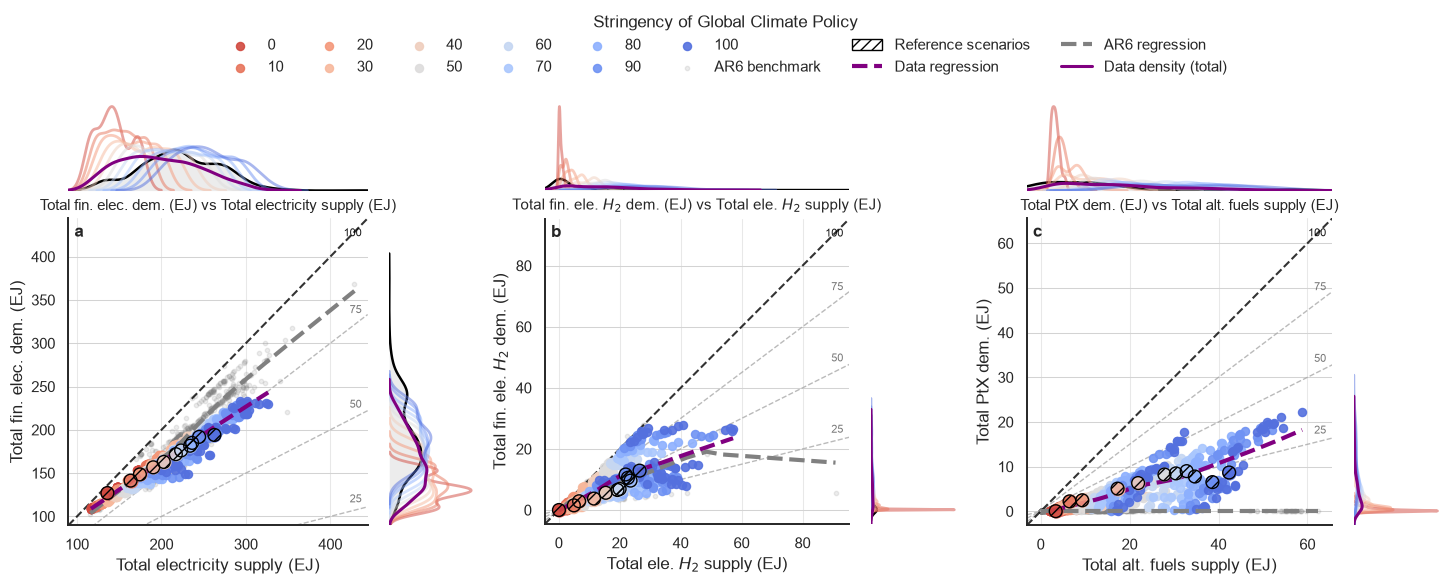

In [5]:
# Add a new column for absolute values of 'EMITOTch'
dataw = data.copy()
dataw['EMITOTchab'] = dataw['EMITOTch'].abs()
ar6['EMITOTchab'] = ar6['EMITOTch'].abs()

# Define variable names for plot
var_names = {'ELETOT': 'Total electricity supply (EJ)',
             'FINELC': 'Total fin. elec. dem. (EJ)',
             'H2GELC': 'Total ele. $H_{2}$ supply (EJ)',
             'FINHH2E': 'Total fin. ele. $H_{2}$ dem. (EJ)',
             'AFUTOT': 'Total alt. fuels supply (EJ)',
             'AFUPtXE': 'Total PtX dem. (EJ)',
             'CP': 'Stringency of Global Climate Policy',
             'benchmark': 'AR6 benchmark',
             'LOESS (benchmark)': 'AR6 regression',
             'LOESS (data)': 'Data regression',
             'total': 'Data density (total)',
             'Highlight': 'Reference scenarios'}

# Define variable pairs for joint plots
var_pairs = [('ELETOT', 'FINELC'), ('H2GELC', 'FINHH2E'), ('AFUTOT', 'AFUPtXE')]

# Filter the data
dataw2050 = dataw[dataw['Period']==2050].sort_values(by=['CP'])
benchmark = ar6[(ar6['Year']==2050)]
benchmark = benchmark[benchmark['FINELC'].values <= benchmark['ELETOT'].values]

# Define the joint encoding, style, regression, and layout
jointencoding = pt.encodings.joint(var_pairs=var_pairs,
                                   color='CP',
                                   category_orders={'CP': list(range(0, 101, 10))},
                                   labels=var_names)
style = pt.Style(palette='coolwarm',
                 reverse_palette=True)
regression = pt.Regression(data=True,
                           data_color='purple',
                           benchmark=True,
                           benchmark_color='grey')
highlight = {'Case': [65, 192, 256, 320, 384, 448,
                      512, 576, 640, 704, 64]}
layout = pt.Layout(panel_letters=True)

# Create plot
pt.multi_jointplot_subfig(dataw2050,
                          jointencoding,
                          benchmark=benchmark,
                          style=style,
                          regression=regression,
                          highlight=highlight,
                          diag_quartiles=True,
                          marginal_show_total=True,
                          marginal_total_color='purple',
                          symmetric_xy=True,
                          layout=layout
                          );

**Generation and use of electricity and electricity-derived fuels in 2050, World.** Each graph represents the scenarios produced in this study, with a color code corresponding to the level of carbon pricing (red to blue, from lowest to highest), and expressed as a percentage between the lowest (0%) and highest (100%) carbon price. The $R_{c}$ reference scenarios for each carbon price category are hatched and black-circled (see table 1). Our data points are compared to the AR6 dataset, vetted C1-C4 scenario categories, represented as grey dots. Each of these two datasets has a lowess regression line: bold dashed purple for this study, and bold dashed grey for AR6. Each quadrant further shows four $\alpha-$reference lines, indicated 25, 50, 75 and 100, representing the $y=\frac{\alpha}{100}x$ coordinates. Marginal distributions for the overall benchmark set, the overall set for this study, and each group of climate policy, are represented for each graph along the x and y axis. **a** Total electricity generation (x-axis, EJ) against total final electricity demand (y-axis, EJ). **b** Total electrolytic hydrogen generation (x-axis, EJ) against total final electrolytic hydrogen demand (y-axis, EJ; calculated as the share of electrolytic hydrogen generated over total hydrogen generation, times the total final hydrogen demand). \textbf{a} Total alternative liquid fuels demand (x-axis, EJ) against total final electrolytic hydrogen-based Power-to-Liquids demand (y-axis, EJ; calculated as the share of electrolytic hydrogen generated over total hydrogen generation, times the total final PtL demand). The share of electrolytic hydrogen in end-uses is calculated using the same share it has in total hydrogen supply, assuming it is a homogeneous good.

# Figure 2
<a id="figure-2"></a>

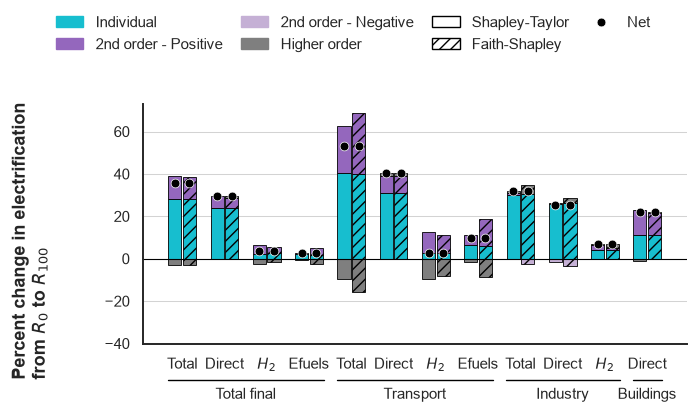

In [6]:
# Define the list of indicators, regions, and climate steps for filtering
indicators = ['FINTELsh', 'FINDELsh', 'FINHELsh', 'FINSELsh',
              'TRATELsh', 'TRADELsh', 'TRAHELsh', 'TRASELsh',
              'INDTELsh', 'INDDELsh', 'INDHELsh','BLGDELsh']
regions = ['World']
cstep = '0-100'
methods = ['Shapley-Taylor', 'Faith-Shapley']
mode = 'absolute'

# Filter the indices_simple DataFrame based on the specified criteria
ims = indices_simple[
    (indices_simple['method'].isin(methods)) & \
    (indices_simple['mode']==mode)  &\
    (indices_simple['Region'].isin(regions)) &\
    (indices_simple['Indicator'].isin(indicators)) &\
    (indices_simple['coalition']=='Total') &\
    (indices_simple['ClimateStep']==cstep)]
ims.drop(columns=['Abs(Contribution)', 'mode'], inplace=True)

# Add 'Sector' and 'Pathway' columns to the ims DataFrame based on the 'Indicator' values
ims['Sector'] = None
ims.loc[ims['Indicator'].str.startswith('FIN'), 'Sector'] = 'Total final'
ims.loc[ims['Indicator'].str.startswith('TRA'), 'Sector'] = 'Transport'
ims.loc[ims['Indicator'].str.startswith('IND'), 'Sector'] = 'Industry'
ims.loc[ims['Indicator'].str.startswith('BLG'), 'Sector'] = 'Buildings'
ims['Pathway'] = None
ims.loc[ims['Indicator'].str.endswith('TELsh'), 'Pathway'] = 'Total elec.'
ims.loc[ims['Indicator'].str.endswith('DELsh'), 'Pathway'] = 'Direct elec.'
ims.loc[ims['Indicator'].str.endswith('HELsh'), 'Pathway'] = '$H_{2}$ elec.'
ims.loc[ims['Indicator'].str.endswith('SELsh'), 'Pathway'] = 'Efuels elec.'

# Define labels, methods, palette
labels = {'TRADELsh': 'Direct', 'TRAHELsh': '$H_{2}$', 'TRASELsh': 'Efuels', 'TRATELsh': 'Total',
          'INDDELsh': 'Direct', 'INDHELsh': '$H_{2}$', 'INDTELsh': 'Total','BLGDELsh': 'Direct',
          'FINDELsh': 'Direct', 'FINHELsh': '$H_{2}$', 'FINSELsh': 'Efuels', 'FINTELsh': 'Total',
          'Total': 'Net'}
methods = ['Shapley-Taylor', 'Faith-Shapley']
imsm = ims[ims['method'].isin(methods)]
palette = {'Individual': colormaps['tab20'].colors[18],
           '2nd order - Positive': colormaps['tab20'].colors[8],
           '2nd order - Negative': colormaps['tab20'].colors[9],
           'Higher order': colormaps['tab20'].colors[14],
           'Total': colormaps['tab20'].colors[10]}

# Sort the DataFrame using a custom order
custom_sort = {'Individual': 0,
               '2nd order - Positive': 1,
               '2nd order - Negative': 2,
               'Higher order': 3,
               'Total': 4}
imsm.sort_values(by='effect',
                 key=lambda x: x.map(custom_sort),
                 inplace=True)

# Define the order of sectors and pathways
sectors = ['Total final', 'Transport', 'Industry', 'Buildings']
pathways = ['Total elec.', 'Direct elec.', '$H_{2}$ elec.', 'Efuels elec.']
category_orders = {'Indicator': indicators,
                   'method': methods}

# Specify encoding, layout, and style
encode = pt.encodings.allocations(
    x='Indicator', y='Contribution', color='effect',
    compare='method', x_hierarchy='Sector',
    category_orders=category_orders,
    color_order=['Individual', '2nd order - Positive', '2nd order - Negative', 'Higher order'],
    labels=labels)
x_title = 'Electrification by sector and fuel'
y_title = 'Percent change in electrification' '\n' r'from $R_{0}$ to $R_{100}$'
layout = pt.Layout(y_title=y_title)
style = pt.Style(hierarchy_line_offset=-0.4,
                 hierarchy_text_offset=-0.04,
                 palette=palette)

# Generate the allocation plot
pt.plot_allocations(imsm, encode,
                    backend='matplotlib',
                    scatter_category={'effect': 'Total'},
                    layout=layout,
                    style=style
                    );

**Decomposition of electrification changes between $R_{0}$ and $R_{100}$ (minimum to maximum carbon pricing schemes), by sector, pathway and interaction order in 2050, World.** Each stacked bar represents, for the total final energy demand and/or a specific end-use sector, the decomposition of the change in the use of electricity or electricity-derived fuels, summed over interaction orders (first, second positive, second negative, higher), irrespectively of the involved features. The net effect is shown as black dots. For each sector and pathway, the Shapley-Taylor (plain) and Faithful-Shapley (hatched) decompositions are presented.

# Figure 3
<a id="figure-3"></a>

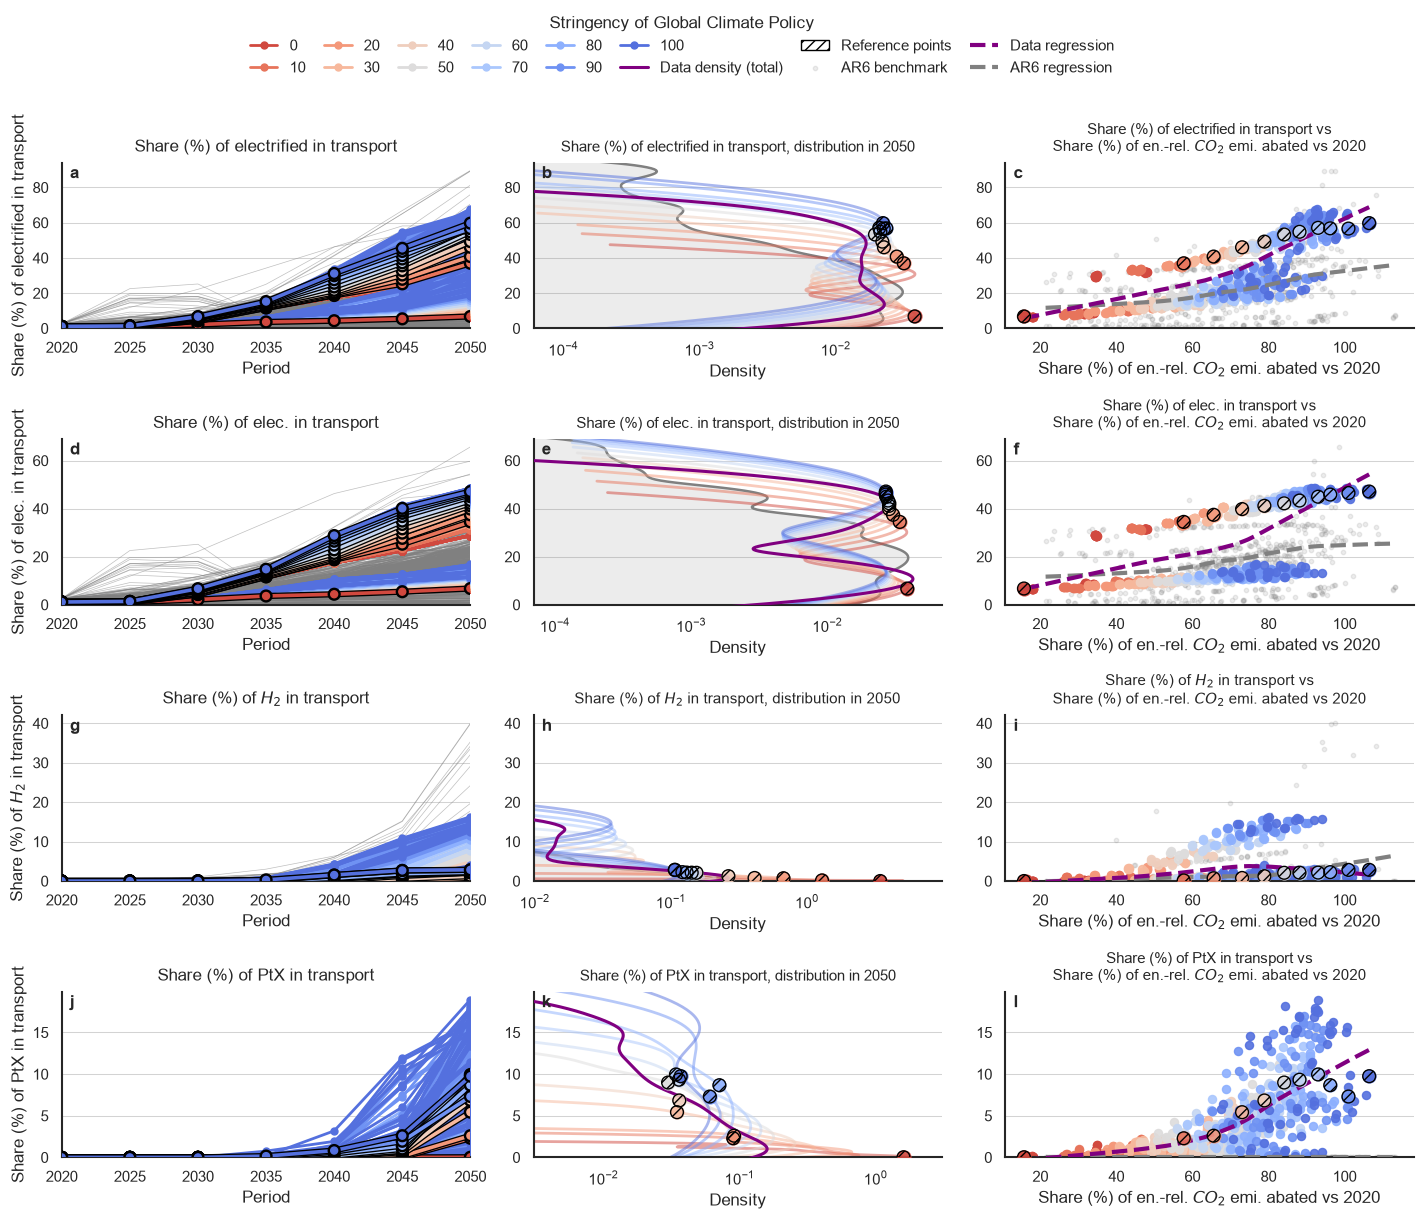

In [7]:
# Add a new column for absolute values of 'EMITOTch'
dataw = data.copy()
dataw['EMITOTchab'] = dataw['EMITOTch'].abs()
data['EMITOTchab'] = data['EMITOTch'].abs()
ar6['EMITOTchab'] = ar6['EMITOTch'].abs()

# Define variable names for plot
var_names = {'FINTELsh': 'Share (%) of tot. ele. in fin. en. dem.',
             'FINDELsh': 'Share (%) of elec. in fin. en. dem.',
             'FINHELsh': 'Share (%) of $H_{2}$ in fin. en. dem.',
             'FINSELsh': 'Share (%) of PtX in fin. en. dem.',
             'TRATELsh': 'Share (%) of electrified in transport',
             'TRADELsh': 'Share (%) of elec. in transport',
             'TRAHELsh': 'Share (%) of $H_{2}$ in transport',
             'TRASELsh': 'Share (%) of PtX in transport',
             'INDDELsh': 'Share (%) of elec. in industry',
             'INDHELsh': 'Share (%) of $H_{2}$ in industry',
             'BLGDELsh': 'Share (%) of elec. in buildings',
             'EMITOTchab': 'Share (%) of en.-rel. $CO_{2}$ emi. abated vs 2020',
             'benchmark': 'AR6 benchmark',
             'CP': 'Stringency of Global Climate Policy',
             'LOESS (benchmark)': 'AR6 regression',
             'LOESS (data)': 'Data regression',
             'total': 'Data density (total)',
             'Highlight': 'Reference points'}

# Define filters & sort dataframe
ar6['Period'] = ar6['Year'].values
variables = ['TRATELsh', 'TRADELsh',
             'TRAHELsh', 'TRASELsh']
dataw.sort_values(by='CP', ascending=True, inplace=True)

# Define encoding, style, regression, and layout for the multiplot grid
encoding = pt.encodings.grid(variables=variables,
                             line_by='Period',
                             color='CP',
                             line_id='Case',
                             scatter_by='EMITOTchab',
                             benchmark_line_id=['Model', 'Scenario'],
                             labels=var_names,
                             aggregate=None,
                             category_orders={'CP': list(range(0, 101, 10))})
style = pt.Style(palette='coolwarm',
                 reverse_palette=True)
regression = pt.Regression(data=True,
                           data_color='purple',
                           benchmark=True,
                           benchmark_color='grey')
highlight = {'Case': [65, 192, 256, 320, 384, 448,
                      512, 576, 640, 704, 64]}
layout = pt.Layout(panel_letters=True)

# Create multiplot grid
pt.multiplot_grid(dataw,
                  benchmark=ar6,
                  encoding=encoding,
                  regression=regression,
                  year=2050,
                  style=style,
                  dist_show_total=True,
                  dist_total_color='purple',
                  highlight=highlight,
                  highlight_lines=highlight,
                  dist_highlight='group',
                  dist_log_x=True,
                  layout=layout
                  );

**Transport electrification trends against IPCC-AR6.** (i) between 2020 and 2050 (left column); (ii) marginal distributions in 2050 (center column) ; (iii) Against \% of $CO_{2}$ emissions reductions against 2020 (right column). Each row represents a pathway (total electrification, electricity, hydrogen, efuels). The color code corresponds to the level of carbon pricing (red to blue, from lowest to highest), and expressed as a percentage between the lowest (0\%) and highest (100\%) carbon price. The $R_{c}$ reference scenarios for each carbon price category are hatched and black-circled (see table 1). Our data points are compared to the AR6 dataset, vetted C1-C4 scenario categories, represented as grey lines, distributions or dots. Each of these two datasets has a lowess regression line for the scatter plot on the right column: bold dashed purple for this study, and bold dashed grey for AR6.

# Figure 4
<a id="figure-4"></a>

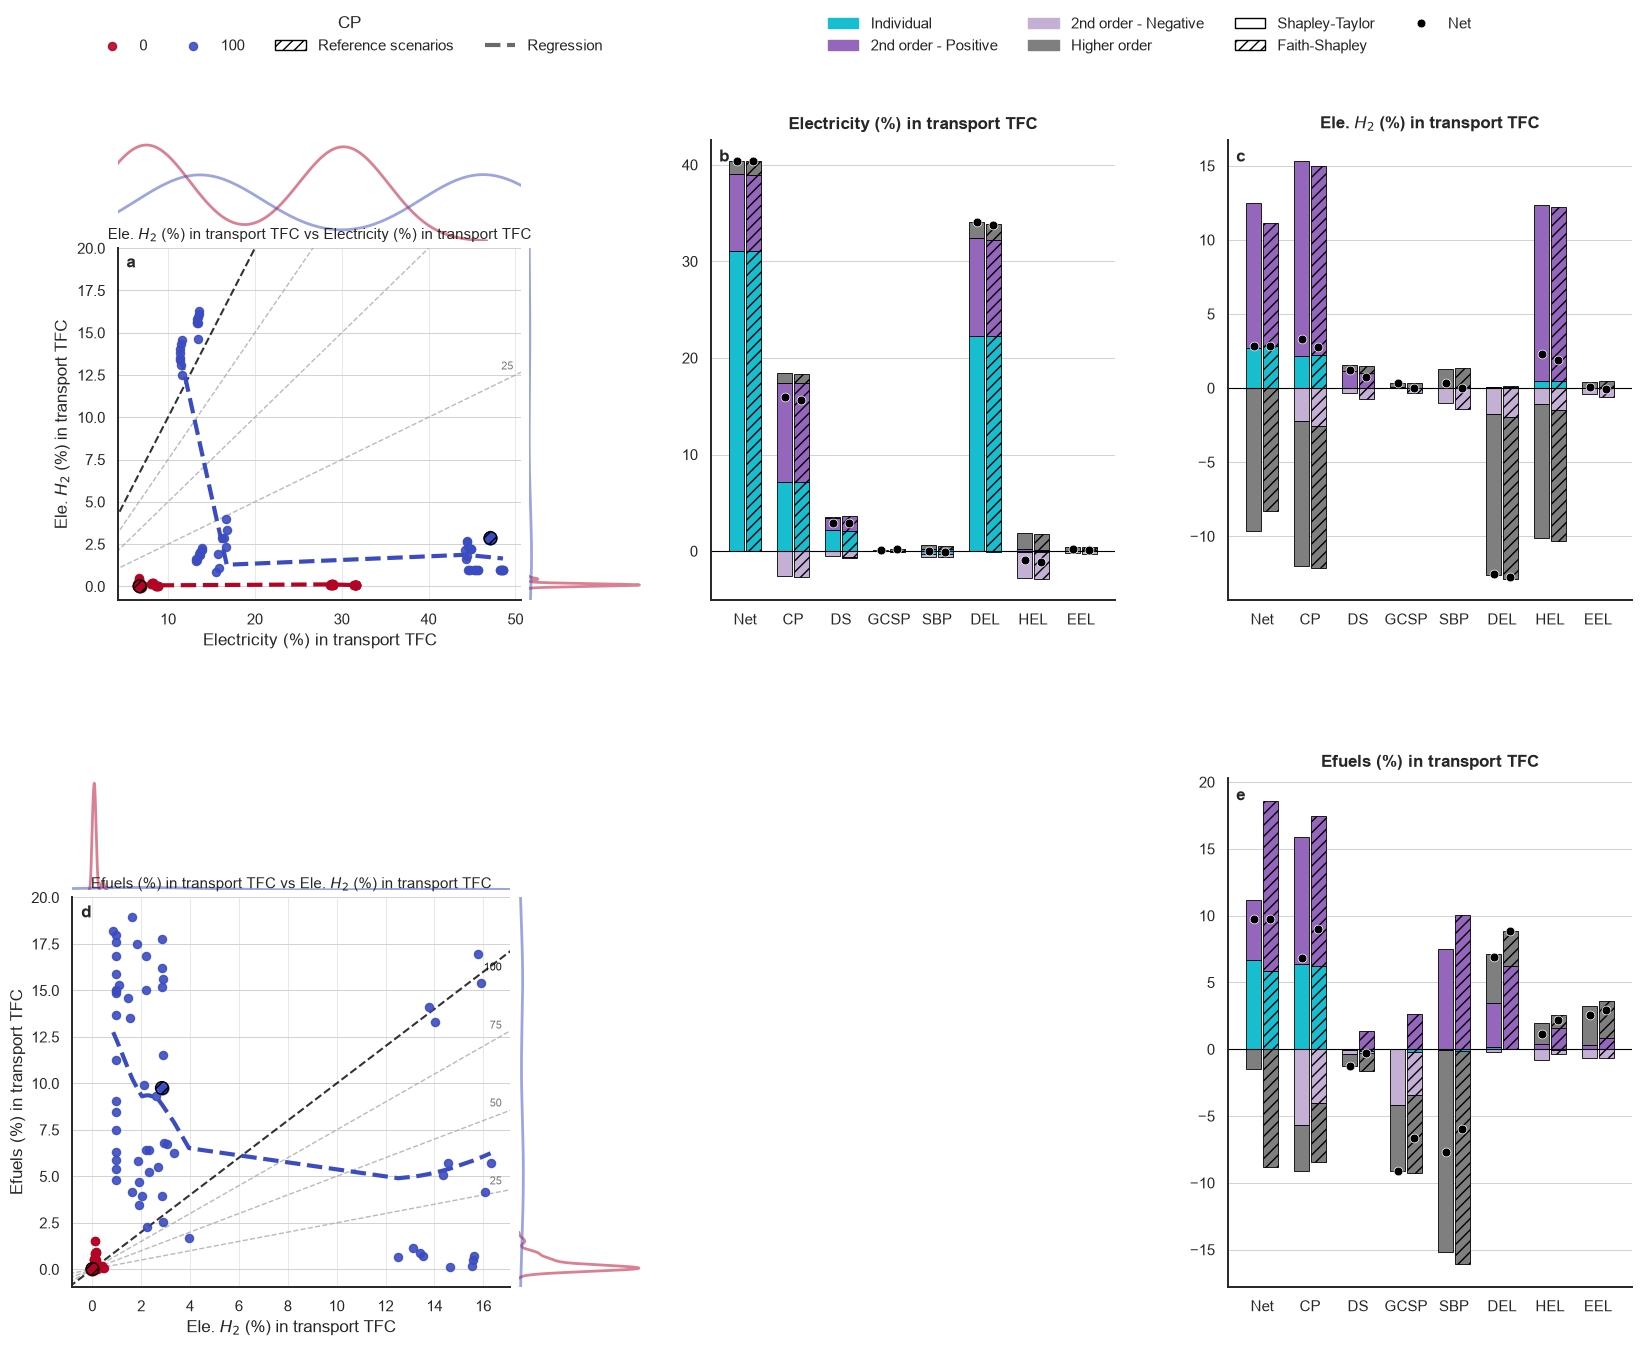

In [8]:
# Filter model dataframe
dataw = data.copy()
dataw = dataw[(dataw['Period']==2050) &\
          (dataw['CP'].isin([0, 100]))].sort_values(by=['CP'])

# Filter indices_simple dataFrame
indicators = ['TRADELsh', 'TRAHELsh', 'TRASELsh']
regions = ['World']
cstep = '0-100'
methods = ['Shapley-Taylor', 'Faith-Shapley']
mode = 'absolute'
coalitions = ['Total', 'CP', 'DS', 'GCSP', 'SBP', 'DEL', 'HEL', 'EEL']
ims = indices_simple[(indices_simple['method'].isin(methods)) & (indices_simple['mode']==mode)  &\
                     (indices_simple['Region'].isin(regions)) & (indices_simple['Indicator'].isin(indicators)) &\
                     (indices_simple['coalition'].isin(coalitions)) & (indices_simple['ClimateStep']==cstep)]
ims.drop(columns=['Abs(Contribution)', 'mode'], inplace=True)

# Filter for specific methods and sort by effect
methods = ['Shapley-Taylor', 'Faith-Shapley']
imsm = ims[ims['method'].isin(methods)]
sectors = ['Transport', 'Industry', 'Buildings', 'Total final']
pathways = ['Direct elec.', '$H_{2}$ elec.', 'Efuels elec.', 'Total elec.']
effects = ['Individual', '2nd order - Positive',
           '2nd order - Negative', 'Higher order']
imsm = ims[ims['coalition'].isin(coalitions)]

# Add 'Sector' and 'Pathway' columns
ims['Sector'] = None
ims.loc[ims['Indicator'].str.startswith('FIN'), 'Sector'] = 'Total final'
ims.loc[ims['Indicator'].str.startswith('TRA'), 'Sector'] = 'Transport'
ims.loc[ims['Indicator'].str.startswith('IND'), 'Sector'] = 'Industry'
ims.loc[ims['Indicator'].str.startswith('BLG'), 'Sector'] = 'Buildings'
ims['Pathway'] = None
ims.loc[ims['Indicator'].str.endswith('TELsh'), 'Pathway'] = 'Total elec.'
ims.loc[ims['Indicator'].str.endswith('DELsh'), 'Pathway'] = 'Direct elec.'
ims.loc[ims['Indicator'].str.endswith('HELsh'), 'Pathway'] = '$H_{2}$ elec.'
ims.loc[ims['Indicator'].str.endswith('SELsh'), 'Pathway'] = 'Efuels elec.'

# Sort the dataframe
custom_sort = {'Individual': 0,
               '2nd order - Positive': 1,
               '2nd order - Negative': 2,
               'Higher order': 3,
               'Total': 4}
imsm.sort_values(by='effect',
                 key=lambda x: x.map(custom_sort),
                 inplace=True)

# Define variable pairs for joint plots
var_pairs = [('TRADELsh', 'TRAHELsh'), ('TRAHELsh', 'TRASELsh')]

# Define labels
labels = {'TRADELsh': 'Electricity (%) in transport TFC',
          'TRAHELsh': r'Ele. $H_{2}$ (%) in transport TFC',
          'TRASELsh': 'Efuels (%) in transport TFC',
          'Highlight': 'Reference scenarios',
          'LOESS (data)': 'Regression',
          'Total': 'Net'}

# Define encodings for joint and allocation plots
jointencoding = pt.encodings.joint(var_pairs=var_pairs,
                                   color='CP',
                                   category_orders={'ClimatePolicy': list(range(0, 101, 10))},
                                   labels=labels)
allocencoding = pt.encodings.allocations(x='coalition', y='Contribution',
                                         facet_col='Indicator',
                                         color='effect', compare='method',
                                         category_orders={'Indicator': indicators,
                                                          'coalition': coalitions},
                                         color_order=effects,
                                         labels=labels)

# Define style, regression, highlight, and layout for the plots
cpcolors = colormaps["coolwarm"].resampled(11)
x = cpcolors(np.arange(0, 1.1, 0.1))
palette = {'Individual': colormaps['tab20'].colors[18],
           '2nd order - Positive': colormaps['tab20'].colors[8],
           '2nd order - Negative': colormaps['tab20'].colors[9],
           'Higher order': colormaps['tab20'].colors[14],
           'Total': colormaps['tab20'].colors[10],
           0: tuple(x[-1]),
           50: tuple(x[5]),
           100: tuple(x[0])}
style = pt.Style(palette=palette)
regression = pt.Regression(
    data=False,
    per_group=True)
highlight = {'Case': [65, 192, 256, 320, 384, 448,
                      512, 576, 640, 704, 64]}
layout = pt.Layout(panel_letters=True,
                   y_max=20,
                   share_y=False)

# Create scatter explain plot
pt.scatter_explain(dataw,
                   jointencoding,
                   imsm,
                   allocencoding,
                   regression=regression,
                   scatter_category={'effect': 'Total'},
                   hide_repeated_panels=True,
                   style=style,
                   highlight=highlight,
                   diag_quartiles=True,
                   symmetric_xy=False,
                   layout=layout
                   );

**The 'electrification cascade' in transport explained by feature, between $R_{0}$ and $R_{100}$ (minimum to maximum carbon pricing schemes), in 2050, World.** Each row of the multi-plot represents a step in the cascade. On the first row (a to c), direct electrification to hydrogen: **(a)** share of electricity in transport total final energy consumption against share of electrolytic $H_{2}$ in transport total final energy consumption, **(b)** explanation by net effect *involving* each feature (x-axis), and order (color code) for the share of electricity in transport total final energy consumption, **(c)** explanation by net effect *involving* each feature (x-axis), and order (color code) for the share of electrolytic $H_{2}$ in transport total final energy consumption. On the second row (d and e), hydrogen to efuels: **(d)** share of electrolytic $H_{2}$ in transport total final energy consumption against share of efuels in transport total final energy consumption, **(e)** explanation by net effect *involving* each feature (x-axis), and order (color code) for the share of efuels in transport total final energy consumption. The $R_{c}$ reference scenarios for each carbon price category are hatched and black-circled (a and c; see table 1). On the decompositions (b, c and e), the net effect is shown as black dots. Pathway, the Shapley-Taylor (plain) and Faithful-Shapley (hatched) decompositions are presented. *Important remark*: each stacked bar group represents the effect *involving* each feature. Therefore, non-individual effects are reported for each feature involved; the bars, apart from the total, are not additive.

# Figure 5
<a id="figure-5"></a>

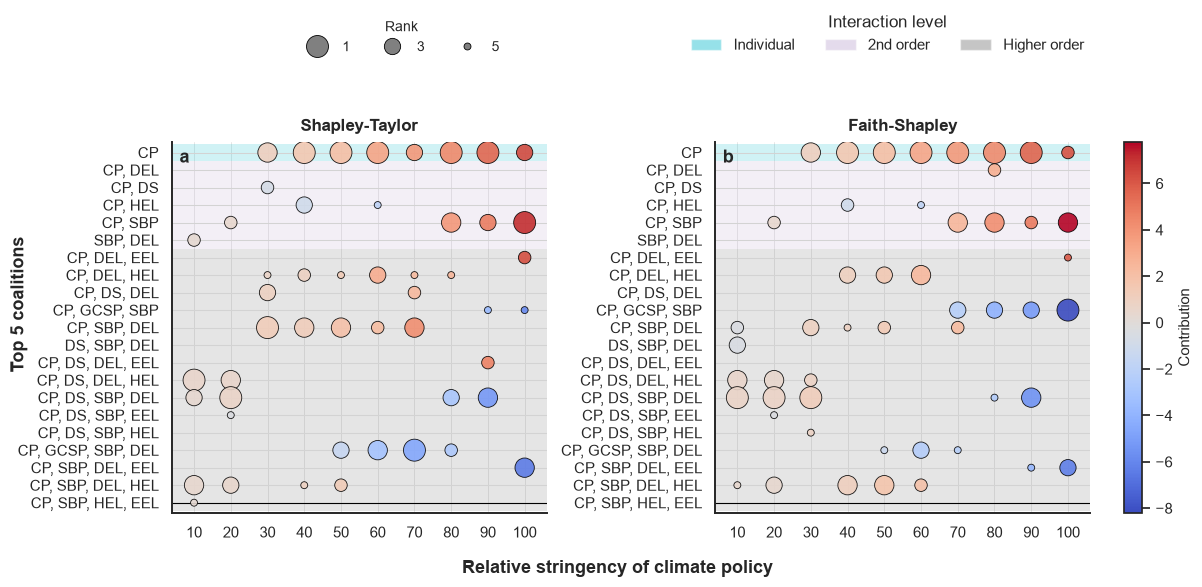

In [9]:
# Define filters for the interactions plot
indicators = ["TRASELsh"]
regions = ["World"]
methods = ["Shapley-Taylor", "Faith-Shapley"]
mode = "absolute"

# Filters
mask = (
    indices["method"].isin(methods)
    & (indices["mode"] == mode)
    & (indices["Region"].isin(regions))
    & (indices["Indicator"].isin(indicators))
    & (indices["FromClimate"] == 0)
    & (indices["coalition"] != "Total")
)
cols = [
    "Abs(Contribution)",
    "Contribution",
    "ToClimate",
    "coalition",
    "Indicator",
    "method",
]
coal_ptx = indices.loc[mask, cols].copy()

# Compute rank per subset
coal_ptx["Rank"] = (
    coal_ptx.groupby(["Indicator", "ToClimate", "method"])["Abs(Contribution)"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

# Top 5 filtering and metadata
coal_ptx_5 = coal_ptx[coal_ptx["Rank"] <= 5].copy()
coal_ptx_5["coalsize"] = coal_ptx_5["coalition"].str.count(",") + 1


# Define a function to get interaction level based on coalition size
def get_interaction_level(size: int) -> str:
    if size == 1:
        return "Individual"
    elif size == 2:
        return "2nd order"
    return "Higher order"

# Map the coalition size to interaction levels and sort the DataFrame
coal_ptx_5["effect"] = coal_ptx_5["coalsize"].map(get_interaction_level)
coal_ptx_5.sort_values(
    by=["coalsize", "coalition"], ascending=[False, False], inplace=True
)

# Define labels for the plot
labels = {
    "TRADELsh": "Direct",
    "TRAHELsh": "$H_{2}$",
    "TRASELsh": "Efuels",
    "INDDELsh": "Direct",
    "INDHELsh": "$H_{2}$",
    "BLGDELsh": "Direct",
    "FINDELsh": "Direct",
    "FINHELsh": "$H_{2}$",
    "FINSELsh": "Efuels",
    "TRATELsh": "Total",
    "effect": "Interaction level",
}

# Color palette, encodings and layout
palette = {
    "Individual": colormaps["tab20"].colors[18],
    "2nd order": colormaps["tab20"].colors[9],
    "Higher order": colormaps["tab20"].colors[14],
}
encode = pt.encodings.heatmap(
    x="ToClimate",
    y="coalition",
    color="Contribution",
    size="Rank",
    facet_col="method",  # No facet_row here
    background="effect",
    category_orders={"ToClimate": list(range(10, 101, 10))},
    labels=labels,
)
layout = pt.Layout(
    x_title="Relative stringency of climate policy",
    y_title="Top 5 coalitions",
    panel_letters=True,
    wspace=0.45,
)

# Plot
result = pt.plot_allocations(
    coal_ptx_5,
    encode,
    graph_type="bubble",
    backend="matplotlib",
    bubble_scope="row",
    bubble_cmap="coolwarm",
    bubble_background_palette=palette,
    bubble_background_alpha=0.2,
    bubble_sizes=(250, 25),
    layout=layout,
    show=False,
)

# Post-processing to match target layout
fig = result.figure
fig.set_size_inches(13.5, 5.8)

# Display Y-axis labels on both panels (a and b)
for item in (
    result.axes.flat if isinstance(result.axes, np.ndarray) else result.axes
):
    ax = item.get("ax_main", item) if isinstance(item, dict) else item
    if isinstance(ax, np.ndarray):
        for sub_ax in ax.flat:
            sub_ax.tick_params(labelleft=True)
    else:
        ax.tick_params(labelleft=True)

# Axes isolation and colorbar identification
cbar_ax = None
main_axes = []

for ax in fig.axes:
    if ax.get_ylabel() == "Contribution" or "Contribution" in ax.get_ylabel():
        cbar_ax = ax
    else:
        main_axes.append(ax)

# Colorbar axis is the thinnest axis if not explicitly identified
if cbar_ax is None:
    cbar_ax = min(fig.axes, key=lambda a: a.get_position().width)
    main_axes = [ax for ax in fig.axes if ax != cbar_ax]

# Sort panels from left to right
main_axes.sort(key=lambda a: a.get_position().x0)
ax_a = main_axes[0]
ax_b = main_axes[-1]

# labelpad is the distance between the axis and the label
ax_a.yaxis.labelpad = 42

# Panels margins adjustment
fig.subplots_adjust(left=0.15, right=0.83, bottom=0.14, top=0.78, wspace=0.45)

# Colorbar repositioning to the right of panel b
bbox_b = ax_b.get_position()
cbar_width = 0.016
cbar_gap = 0.025
cbar_ax.set_position(
    [bbox_b.x1 + cbar_gap, bbox_b.y0, cbar_width, bbox_b.height]
)

# Center the colorbar label
for txt in fig.texts:
    val = txt.get_text()
    if "Top 5" in val:
        txt.set_position((0.03, txt.get_position()[1]))
    elif "stringency" in val:
        txt.set_position((0.48, 0.03))

display(fig);

**Reconfiguration of the explanation structure by feature through the mitigation space, for Power-to-Liquids, World, 2050.** Each of the heatmaps ranks, for each of the 10 $R_{0}-R_{c}$ finite changes, the top 5 coalitions (bubble size) and their contribution to the change in share of PtL in transport final energy consumption (color scale). Interaction order is captured in the color code in the background. The two subplots compare the two attribution methods.